# HCMST Data Cleaning and SES Variable Preparation

**Raw dataset:** `HCMST_ver_3.04.dta`  
**Source:** HCMST 2017–2020–2022 combined dataset  
**Download date:** 29 september 2026

## 1. Load the HCMST Dataset

Import the required Python library and load the raw HCMST Stata dataset from `data/raw/`.

In [61]:
import pandas as pd

df = pd.read_stata("../data/raw/HCMST_ver_3.04.dta")

## 2. Check Dataset Dimensions

Check the number of respondents (rows) and variables (columns) in the dataset.

In [62]:
df.shape

(4002, 387)

## 3. Preview the Dataset

Display the first five rows to inspect the dataset structure and confirm that it loaded correctly.

In [63]:
df.head()

,caseid_new,weight1,weight2,ppage,ppagecat,ppagect4,ppeduc,ppeducat,ppethm,ppgender,...,w3_mbtiming_year,w3_mbtiming_month,w3_q5,w3_q6,w3_q7,w3_q8,w3_q9,w3_q10,w3_nonmbtiming_year,w3_nonmbtiming_month
0,22526,4265,4265.0,52,45-54,45-59,bachelors degree,bachelor's degree or higher,hispanic,female,...,NaN,NaN,yes,yes,"no, did not marry [xNameP]","No, we have not gotten a domestic partnership ...",NaN,NaN,NaN,NaN
1,23286,16485,16485.0,28,25-34,18-29,masters degree,bachelor's degree or higher,"white, non-hispanic",female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25495,52464,NaN,49,45-54,45-59,high school graduate - high school diploma or ...,high school,"black, non-hispanic",female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,26315,4575,4575.0,31,25-34,30-44,associate degree,some college,"white, non-hispanic",male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,27355,12147,NaN,35,35-44,30-44,high school graduate - high school diploma or ...,high school,"white, non-hispanic",male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Identify Relevant Baseline (Wave 1) SES Variables

Search the dataset column names to identify the baseline SES variables for household income, respondent education, and partner education.

In [64]:
[col for col in df.columns if "inc" in col.lower()]

['ppincimp', 'hhinc', 'pp2_ppincimp', 'pp3_ppincimp']

In [65]:
[col for col in df.columns if "educ" in col.lower()]

['ppeduc',
 'ppeducat',
 'pp2_ppeduc',
 'pp2_ppeducat',
 'pp_ieduc1',
 'pp2_ieduc2',
 'pp3_ppeduc',
 'pp3_ppeducat']

In [66]:
[col for col in df.columns if "q10" in col.lower()]

['q10', 'w2_q10', 'w3_q10']

## 5. Inspect SES Variable Categories and Missing Values

Examine the response categories and frequencies for household income, respondent education, and partner education, including missing or refused responses.

In [67]:
print("INCOME:")
print(df["ppincimp"].value_counts(dropna=False))

print("\nRESPONDENT EDUCATION:")
print(df["ppeduc"].value_counts(dropna=False))

print("\nPARTNER EDUCATION:")
print(df["q10"].value_counts(dropna=False))

INCOME:
ppincimp
$60,000 to $74,999      461
$50,000 to $59,999      422
$40,000 to $49,999      397
$85,000 to $99,999      311
$100,000 to $124,999    300
$75,000 to $84,999      296
$35,000 to $39,999      260
$20,000 to $24,999      219
$25,000 to $29,999      212
$30,000 to $34,999      201
$125,000 to $149,999    162
$15,000 to $19,999      157
$175,000 or more        127
$10,000 to $12,499      106
$7,500 to $9,999        100
$150,000 to $174,999     87
$12,500 to $14,999       85
$5,000 to $7,499         54
less than $5,000         45
Name: count, dtype: int64

RESPONDENT EDUCATION:
ppeduc
high school graduate - high school diploma or the equivalent (ged)    987
some college, no degree                                               905
bachelors degree                                                      864
masters degree                                                        383
associate degree                                                      305
professional or doctorate

### Missing Data Decisions

Household income (`ppincimp`) and respondent education (`ppeduc`) contained valid responses for all 4,002 respondents.

Partner education (`q10`) contained 1,000 unavailable responses, comprising 992 missing values and 8 explicit refusals. These cases are retained as missing rather than treated as substantive education categories.

## 6. Inspect Full Education Category Distributions

Display the complete category distributions for respondent and partner education to determine how the variables should be recoded.

In [68]:
print(df["ppeduc"].value_counts(dropna=False).to_string())

ppeduc
high school graduate - high school diploma or the equivalent (ged)    987
some college, no degree                                               905
bachelors degree                                                      864
masters degree                                                        383
associate degree                                                      305
professional or doctorate degree                                      160
12th grade no diploma                                                 118
11th grade                                                             98
10th grade                                                             71
7th or 8th grade                                                       51
9th grade                                                              49
5th or 6th grade                                                        8
1st, 2nd, 3rd, or 4th grade                                             2
no formal education            

In [69]:
print(df["q10"].value_counts(dropna=False).to_string())

q10
NaN                                 992
hs graduate or ged                  737
some college, no degree             701
bachelor's degree                   609
master's degree                     324
associate degree                    267
professional or doctorate degree    114
12th grade no diploma                78
11th grade                           51
10th grade                           49
7th or 8th grade                     27
9th grade                            25
5th or 6th grade                     13
refused                               8
1st - 4th grade                       5
no formal education                   2


## 7. Recode Education Variables

Respondent and partner educational attainment are collapsed into four comparable categories: less than high school, high school, some college, and bachelor's degree or above. Refused and unavailable responses are retained as missing rather than treated as substantive education categories.

In [70]:
import numpy as np

# Recode respondent education
respondent_edu_map = {
    "no formal education": "Less than HS",
    "1st, 2nd, 3rd, or 4th grade": "Less than HS",
    "5th or 6th grade": "Less than HS",
    "7th or 8th grade": "Less than HS",
    "9th grade": "Less than HS",
    "10th grade": "Less than HS",
    "11th grade": "Less than HS",
    "12th grade no diploma": "Less than HS",
    "high school graduate - high school diploma or the equivalent (ged)": "HS",
    "some college, no degree": "Some college",
    "associate degree": "Some college",
    "bachelors degree": "Bachelor's+",
    "masters degree": "Bachelor's+",
    "professional or doctorate degree": "Bachelor's+"
}

df["respondent_edu_group"] = df["ppeduc"].map(respondent_edu_map)


# Recode partner education
partner_edu_map = {
    "no formal education": "Less than HS",
    "1st - 4th grade": "Less than HS",
    "5th or 6th grade": "Less than HS",
    "7th or 8th grade": "Less than HS",
    "9th grade": "Less than HS",
    "10th grade": "Less than HS",
    "11th grade": "Less than HS",
    "12th grade no diploma": "Less than HS",
    "hs graduate or ged": "HS",
    "some college, no degree": "Some college",
    "associate degree": "Some college",
    "bachelor's degree": "Bachelor's+",
    "master's degree": "Bachelor's+",
    "professional or doctorate degree": "Bachelor's+",
    "refused": np.nan
}

df["partner_edu_group"] = df["q10"].map(partner_edu_map)

In [71]:
print("RESPONDENT EDUCATION GROUPS:")
print(df["respondent_edu_group"].value_counts(dropna=False))

print("\nPARTNER EDUCATION GROUPS:")
print(df["partner_edu_group"].value_counts(dropna=False))

RESPONDENT EDUCATION GROUPS:
respondent_edu_group
Bachelor's+     1407
Some college    1210
HS               987
Less than HS     398
Name: count, dtype: int64

PARTNER EDUCATION GROUPS:
partner_edu_group
Bachelor's+     1047
NaN             1000
Some college     968
HS               737
Less than HS     250
Name: count, dtype: int64


### Comparing Respondent and Partner Education

 This comparison was created as a secondary SES-related measure to capture educational similarity or mismatch within the Wave 1 couples

**Why it may be useful:**  
It could be used later to explore whether couples with similar or different education levels show different relationship-stability outcomes across later waves

In [101]:
education_order = {
    "Less than HS": 1,
    "HS": 2,
    "Some college": 3,
    "Bachelor's+": 4
}

df["respondent_edu_score"] = df["respondent_edu_group"].map(education_order)
df["partner_edu_score"] = df["partner_edu_group"].map(education_order)

In [103]:
def compare_education(row):
    if pd.isna(row["respondent_edu_score"]) or pd.isna(row["partner_edu_score"]):
        return np.nan
    elif row["respondent_edu_score"] > row["partner_edu_score"]:
        return "Respondent higher"
    elif row["respondent_edu_score"] < row["partner_edu_score"]:
        return "Partner higher"
    else:
        return "Same education level"

df["education_comparison"] = df.apply(compare_education, axis=1)

In [104]:
df["education_comparison"].value_counts(dropna=False)

education_comparison
Same education level    1478
NaN                     1000
Partner higher           826
Respondent higher        698
Name: count, dtype: int64

## 8. Recode Household Income

In [72]:
# coding the 19 income brackets from lowest to highest

income_order = {
    "less than $5,000": 1,
    "$5,000 to $7,499": 2,
    "$7,500 to $9,999": 3,
    "$10,000 to $12,499": 4,
    "$12,500 to $14,999": 5,
    "$15,000 to $19,999": 6,
    "$20,000 to $24,999": 7,
    "$25,000 to $29,999": 8,
    "$30,000 to $34,999": 9,
    "$35,000 to $39,999": 10,
    "$40,000 to $49,999": 11,
    "$50,000 to $59,999": 12,
    "$60,000 to $74,999": 13,
    "$75,000 to $84,999": 14,
    "$85,000 to $99,999": 15,
    "$100,000 to $124,999": 16,
    "$125,000 to $149,999": 17,
    "$150,000 to $174,999": 18,
    "$175,000 or more": 19
}

df["income_ordinal"] = df["ppincimp"].map(income_order)

In [73]:
print(df["income_ordinal"].value_counts(dropna=False).sort_index())

income_ordinal
1      45
2      54
3     100
4     106
5      85
6     157
7     219
8     212
9     201
10    260
11    397
12    422
13    461
14    296
15    311
16    300
17    162
18     87
19    127
Name: count, dtype: int64


### Create Income Tertiles for Interaction Analysis

In [74]:
income_numeric = df["income_ordinal"].astype(int)

df["income_tertile"] = pd.qcut(
    income_numeric,
    q=3,
    labels=["Low", "Middle", "High"]
)

In [75]:
print(df["income_tertile"].value_counts(dropna=False))

income_tertile
Low       1439
High      1283
Middle    1280
Name: count, dtype: int64


### SES Recoding Decisions

Household income (`ppincimp`) was converted from 19 ordered income brackets into an ordinal scale ranging from 1 (lowest bracket) to 19 (highest bracket). A separate low/middle/high income tertile variable was created for later interaction analysis.

Respondent education (`ppeduc`) and partner education (`q10`) were collapsed into four comparable categories: Less than HS, HS, Some college, and Bachelor's+.

Missing and refused partner-education responses were retained as missing values.

## 9. Create Summary Statistics for SES Variables

In [76]:
summary_table = pd.DataFrame({
    "Variable": [
        "Household income (ordinal)",
        "Respondent education",
        "Partner education"
    ],
    "N": [
        df["income_ordinal"].notna().sum(),
        df["respondent_edu_group"].notna().sum(),
        df["partner_edu_group"].notna().sum()
    ],
    "Missing": [
        df["income_ordinal"].isna().sum(),
        df["respondent_edu_group"].isna().sum(),
        df["partner_edu_group"].isna().sum()
    ]
})

summary_table

,Variable,N,Missing
0,Household income (ordinal),4002,0
1,Respondent education,4002,0
2,Partner education,3002,1000


### household income

note: the following outputs are numbers are the mean/median/mode of the 1–19 income bracket codes rather than the actual dollar income

In [ ]:
income_stats = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode"],
    "Value": [
        income_numeric.mean(),
        income_numeric.median(),
        income_numeric.mode().iloc[0]
    ]
})

income_stats

,Statistic,Value
0,Mean,11.406297
1,Median,12.000000
2,Mode,13.000000


Interpreting the above output: 
Mean = 11.41 → average coded income category is around bracket 11–12
Median = 12 → the middle respondent falls in bracket 12 = $50,000–$59,999
Mode = 13 → the most common bracket is 13 = $60,000–$74,999

## 10. Calculate SES Category Percentages

In [80]:
respondent_edu_percent = (
    df["respondent_edu_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

partner_edu_percent = (
    df["partner_edu_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

income_tertile_percent = (
    df["income_tertile"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("RESPONDENT EDUCATION (%)")
print(respondent_edu_percent)

print("\nPARTNER EDUCATION (%)")
print(partner_edu_percent)

print("\nINCOME TERTILES (%)")
print(income_tertile_percent)

RESPONDENT EDUCATION (%)
respondent_edu_group
Bachelor's+     35.2
Some college    30.2
HS              24.7
Less than HS     9.9
Name: proportion, dtype: float64

PARTNER EDUCATION (%)
partner_edu_group
Bachelor's+     34.9
Some college    32.2
HS              24.6
Less than HS     8.3
Name: proportion, dtype: float64

INCOME TERTILES (%)
income_tertile
Low       36.0
High      32.1
Middle    32.0
Name: proportion, dtype: float64


In [82]:
#saving existing tables

summary_table.to_csv("../output/tables/ses_summary.csv", index=False)
income_stats.to_csv("../output/tables/income_summary_stats.csv", index=False)

In [85]:
#saving percentile tables

respondent_edu_percent.to_csv("../output/tables/respondent_education_percent.csv")
partner_edu_percent.to_csv("../output/tables/partner_education_percent.csv")
income_tertile_percent.to_csv("../output/tables/income_tertile_percent.csv")

## 11. Create SES Figures

### Income tertiles

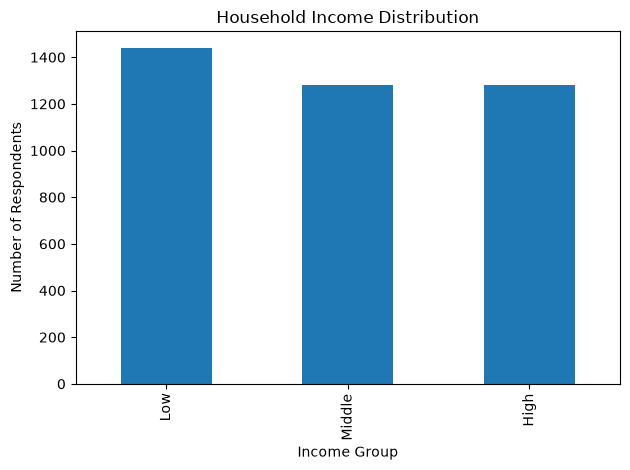

In [86]:
import matplotlib.pyplot as plt

df["income_tertile"].value_counts().reindex(
    ["Low", "Middle", "High"]
).plot(kind="bar")

plt.xlabel("Income Group")
plt.ylabel("Number of Respondents")
plt.title("Household Income Distribution")
plt.tight_layout()

plt.savefig("../output/figures/income_tertiles.png")
plt.show()

### Respondent education

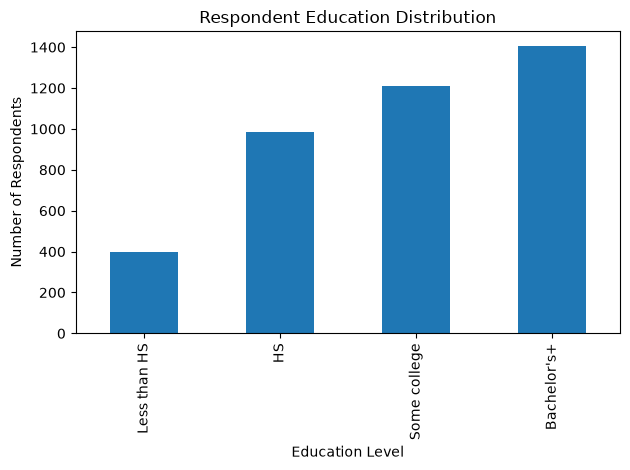

In [87]:
df["respondent_edu_group"].value_counts().reindex(
    ["Less than HS", "HS", "Some college", "Bachelor's+"]
).plot(kind="bar")

plt.xlabel("Education Level")
plt.ylabel("Number of Respondents")
plt.title("Respondent Education Distribution")
plt.tight_layout()

plt.savefig("../output/figures/respondent_education.png")
plt.show()

### Partner education

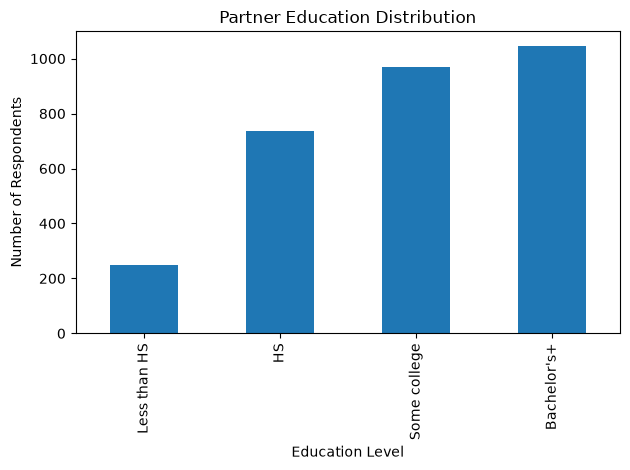

In [88]:
df["partner_edu_group"].value_counts().reindex(
    ["Less than HS", "HS", "Some college", "Bachelor's+"]
).plot(kind="bar")

plt.xlabel("Education Level")
plt.ylabel("Number of Respondents")
plt.title("Partner Education Distribution")
plt.tight_layout()

plt.savefig("../output/figures/partner_education.png")
plt.show()

## 12. Identify Variables Needed for the Shared Analysis Dataset

> **Note for person B & C:**
> This section is a preliminary check of potentially relevant raw variables for the relationship-stability and race analyses. Please verify the variable labels, coding, and suitability yourselves before using them in your analysis. Once you have confirmed your own variables, feel free to replace or remove this section.

In [90]:
print("RELATIONSHIP END / STABILITY VARIABLES:")
print([col for col in df.columns if "relationship" in col.lower() or "q5" in col.lower() or "q9" in col.lower()])

print("\nRELATIONSHIP DURATION VARIABLES:")
print([col for col in df.columns if "duration" in col.lower()])

print("\nRESPONDENT RACE VARIABLES:")
print([col for col in df.columns if "ppethm" in col.lower()])

print("\nPARTNER RACE VARIABLES:")
print([col for col in df.columns if "q6b" in col.lower()])

print("\nEARNINGS COMPARISON VARIABLES:")
print([col for col in df.columns if "q23" in col.lower()])

RELATIONSHIP END / STABILITY VARIABLES:
['pphhcomp11_member2_relationship', 'pphhcomp11_member3_relationship', 'pphhcomp11_member4_relationship', 'pphhcomp11_member5_relationship', 'pphhcomp11_member6_relationship', 'pphhcomp11_member7_relationship', 'pphhcomp11_member8_relationship', 'pphhcomp11_member9_relationship', 'pphhcomp11_member10_relationship', 'pphhcomp11_member11_relationship', 'pphhcomp11_member12_relationship', 'pphhcomp11_member13_relationship', 'pphhcomp11_member14_relationship', 'pphhcomp11_member15_relationship', 'q5', 'q9', 'how_long_relationship', 'relationship_quality', 'w2_q5', 'w2_q9', 'w3_q5', 'w3_q9']

RELATIONSHIP DURATION VARIABLES:
['duration', 'w2_duration', 'w3_duration']

RESPONDENT RACE VARIABLES:
['ppethm', 'pp2_ppethm', 'pp3_ppethm']

PARTNER RACE VARIABLES:
['q6b']

EARNINGS COMPARISON VARIABLES:
['q23']


In [91]:
for var in ["w2_q5", "w2_q9", "w3_q5", "w3_q9", "how_long_relationship", "q23", "q6b"]:
    print("\n", var)
    print(df[var].value_counts(dropna=False))


 w2_q5
w2_q5
NaN    3127
yes     650
no      225
Name: count, dtype: int64

 w2_q9
w2_q9
NaN                                   3778
we broke up                            182
other (please describe)                 35
[partner] passed away, is deceased       7
Name: count, dtype: int64

 w3_q5
w3_q5
NaN    3434
yes     472
no       96
Name: count, dtype: int64

 w3_q9
w3_q9
NaN                                  3906
We broke up                            71
Other (please describe)                16
[xNameP] passed away, is deceased       8
Refused                                 1
Name: count, dtype: int64

 how_long_relationship
how_long_relationship
NaN     1019
4.0      186
1.5      134
8.0      116
9.0      112
        ... 
70.0       2
71.0       1
68.0       1
76.0       1
0.0        1
Name: count, Length: 76, dtype: int64

 q23
q23
i earned more                      1332
partner earned more                1272
NaN                                 992
we earned about the same amou

### Relative earnings SES measure

In [93]:
print(df["q23"].value_counts(dropna=False).to_string())

q23
i earned more                      1332
partner earned more                1272
NaN                                 992
we earned about the same amount     375
refused                              31


### Partner race & ethnicity categories

In [94]:
print(df["q6b"].value_counts(dropna=False).to_string())

q6b
white                                2528
NaN                                   990
black or african american             253
other (please specify)                120
asian or pacific islander              65
american indian, aleut, or eskimo      25
refused                                21


In [97]:
[col for col in df.columns if "q6" in col.lower()]

['q6a', 'q6b', 'w2_q6', 'w3_q6']

In [98]:
print(df["q6a"].value_counts(dropna=False).to_string())

q6a
no (not latino or hispanic)                2768
NaN                                         990
yes, mexican, mexican american, chicano     109
yes, other latino/hispanic                   71
yes, puerto rican                            45
yes, cuban                                   10
refused                                       9


In [99]:
print("WAVE 2 PARTNER RACE/ETHNICITY:")
print(df["w2_q6"].value_counts(dropna=False).to_string())

print("\nWAVE 3 PARTNER RACE/ETHNICITY:")
print(df["w3_q6"].value_counts(dropna=False).to_string())

WAVE 2 PARTNER RACE/ETHNICITY:
w2_q6
NaN    3352
yes     423
no      227

WAVE 3 PARTNER RACE/ETHNICITY:
w3_q6
NaN    3530
yes     342
no      130


### Relationship duration in years

In [95]:
print(df["how_long_relationship"].describe())
print("\nMissing:", df["how_long_relationship"].isna().sum())

count    2983.000000
mean       17.708332
std        15.658864
min         0.000000
25%         5.000000
50%        13.000000
75%        26.000000
max        76.000000
Name: how_long_relationship, dtype: float64

Missing: 1019


### reasons relationship ended  

In [96]:
print(df["w3_q9"].value_counts(dropna=False).to_string())

w3_q9
NaN                                  3906
We broke up                            71
Other (please describe)                16
[xNameP] passed away, is deceased       8
Refused                                 1


## 13. Create and Save Shared Analysis Dataset

Create a smaller processed dataset containing the cleaned SES variables and the raw variables needed for the remaining group analyses

In [105]:
variables_to_keep = [
    # ID / weights
    "caseid_new",
    "weight1",
    "weight2",
    "weight3",

    # Raw SES
    "ppincimp",
    "ppeduc",
    "q10",
    "q23",

    # Your cleaned SES variables
    "income_ordinal",
    "income_tertile",
    "respondent_edu_group",
    "partner_edu_group",
    "respondent_edu_score",
    "partner_edu_score",
    "education_comparison",

    # Relationship variables for Person B
    "w2_q5",
    "w2_q9",
    "w3_q5",
    "w3_q9",
    "how_long_relationship",

    # Race variables for Person C
    "ppethm",
    "pp2_ppethm",
    "pp3_ppethm",
    "q6a",
    "q6b"
]

shared_df = df[variables_to_keep].copy()

In [106]:
shared_df.shape

(4002, 25)

In [107]:
shared_df.to_csv(
    "../data/processed/hcmst_analysis_base.csv",
    index=False
)